In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def vf(t, z, mu, a):
    x, y = z
    return np.array([y, x - x**2 + mu*y + a*x*y])

def jacobian(x, y, mu, a):
    return np.array([
        [0.0, 1.0],
        [1.0 - 2.0*x + a*y, mu + a*x]
    ])

def saddle_eigendata(mu):
    # Jacobian at the saddle (0,0)
    J = np.array([[0.0, 1.0],
                  [1.0, mu]])
    vals, vecs = np.linalg.eig(J)

    idx_u = np.argmax(vals.real)
    idx_s = np.argmin(vals.real)

    lam_u = vals[idx_u].real
    lam_s = vals[idx_s].real

    vu = vecs[:, idx_u].real
    vs = vecs[:, idx_s].real

    vu = vu / np.linalg.norm(vu)
    vs = vs / np.linalg.norm(vs)

    return lam_s, lam_u, vs, vu

def H(x, y):
    return 0.5*y**2 - 0.5*x**2 + x**3/3.0

In [3]:
def integrate_orbit(z0, mu, a, T=80.0, backward=False, max_step=0.02, bound=5.0):
    t_span = (0.0, -T) if backward else (0.0, T)

    def stop_event(t, z):
        return bound - max(abs(z[0]), abs(z[1]))
    stop_event.terminal = True
    stop_event.direction = -1

    sol = solve_ivp(
        lambda t, z: vf(t, z, mu, a),
        t_span,
        z0,
        rtol=1e-9,
        atol=1e-11,
        max_step=max_step,
        events=stop_event
    )
    return sol.t, sol.y[0], sol.y[1]

def plot_saddle_manifolds(ax, mu, a, eps=1e-5, T=60.0):
    lam_s, lam_u, vs, vu = saddle_eigendata(mu)

    # unstable manifold: integrate forward from +/- eps * vu
    for sgn in [+1, -1]:
        z0 = sgn * eps * vu
        _, x, y = integrate_orbit(z0, mu, a, T=T, backward=False)
        ax.plot(x, y, lw=2.5, color="crimson", label=None)

    # stable manifold: integrate backward from +/- eps * vs
    for sgn in [+1, -1]:
        z0 = sgn * eps * vs
        _, x, y = integrate_orbit(z0, mu, a, T=T, backward=True)
        ax.plot(x, y, lw=2.0, ls="--", color="royalblue", label=None)

def normalized_field(mu, a, xlim, ylim, n=45):
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(xs, ys)

    U = Y
    V = X - X**2 + mu*Y + a*X*Y

    S = np.sqrt(U**2 + V**2) + 1e-12
    U = U / S
    V = V / S

    return X, Y, U, V

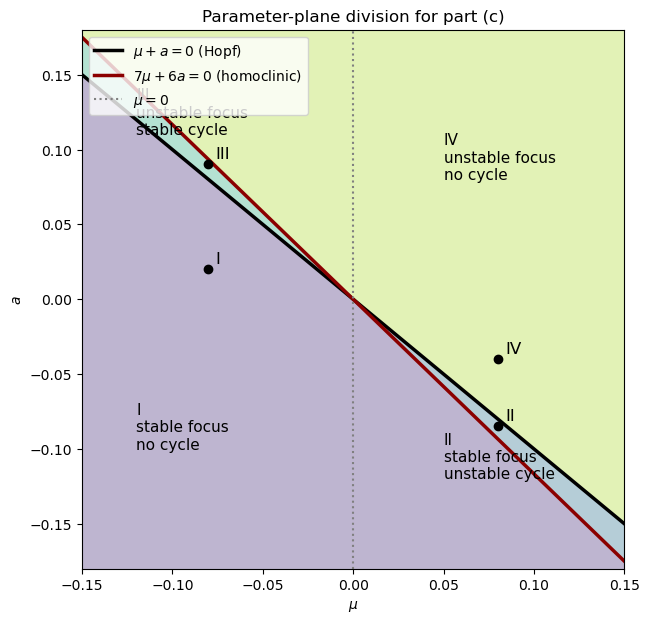

In [4]:
mu_min, mu_max = -0.15, 0.15
a_min, a_max = -0.18, 0.18

MU, AA = np.meshgrid(
    np.linspace(mu_min, mu_max, 600),
    np.linspace(a_min, a_max, 600)
)

region = np.zeros_like(MU, dtype=int)
region[(MU + AA < 0) & (7*MU + 6*AA < 0)] = 1   # Region I
region[(MU + AA < 0) & (7*MU + 6*AA > 0)] = 2   # Region II
region[(MU + AA > 0) & (7*MU + 6*AA < 0)] = 3   # Region III
region[(MU + AA > 0) & (7*MU + 6*AA > 0)] = 4   # Region IV

fig, ax = plt.subplots(figsize=(7, 7))
ax.contourf(MU, AA, region, levels=[0.5, 1.5, 2.5, 3.5, 4.5], alpha=0.35)

mu = np.linspace(mu_min, mu_max, 400)
ax.plot(mu, -mu, lw=2.5, color="black", label=r'$\mu+a=0$ (Hopf)')
ax.plot(mu, -(7/6)*mu, lw=2.5, color="darkred", label=r'$7\mu+6a=0$ (homoclinic)')
ax.axvline(0.0, lw=1.5, ls=":", color="gray", label=r'$\mu=0$')

# sample points
samples = {
    "I":   (-0.08,  0.02),
    "II":  ( 0.08, -0.085),
    "III": (-0.08,  0.09),
    "IV":  ( 0.08, -0.04),
}
for name, (mu0, a0) in samples.items():
    ax.plot(mu0, a0, "ko")
    ax.text(mu0 + 0.004, a0 + 0.004, name, fontsize=12)

ax.text(-0.12, -0.10, "I\nstable focus\nno cycle", fontsize=11)
ax.text( 0.05, -0.12, "II\nstable focus\nunstable cycle", fontsize=11)
ax.text(-0.12,  0.11, "III\nunstable focus\nstable cycle", fontsize=11)
ax.text( 0.05,  0.08, "IV\nunstable focus\nno cycle", fontsize=11)

ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$a$')
ax.set_title("Parameter-plane division for part (c)")
ax.legend(loc="upper left")
ax.set_xlim(mu_min, mu_max)
ax.set_ylim(a_min, a_max)
plt.show()

In [5]:
def plot_phase_portrait(ax, mu, a, title="", xlim=(-0.25, 1.65), ylim=(-0.85, 0.85),
                        cycle=None, cycle_seed=(1.25, 0.0), T_cycle=250.0):

    # background normalized vector field
    X, Y, U, V = normalized_field(mu, a, xlim, ylim, n=45)
    ax.streamplot(X, Y, U, V, density=1.0, color="0.75", linewidth=0.8, arrowsize=0.9)

    # equilibria
    ax.plot(0.0, 0.0, "ks", ms=7)
    ax.plot(1.0, 0.0, "ko", ms=7)
    ax.text(0.02, 0.03, "(0,0)", fontsize=10)
    ax.text(1.02, 0.03, "(1,0)", fontsize=10)

    # saddle manifolds
    plot_saddle_manifolds(ax, mu, a, eps=1e-5, T=70.0)

    # a few generic forward trajectories
    seeds = [
        (0.25, 0.20), (0.25, -0.20),
        (0.65, 0.30), (0.65, -0.30),
        (1.15, 0.12), (1.15, -0.12),
        (1.35, 0.00)
    ]
    for z0 in seeds:
        _, x, y = integrate_orbit(np.array(z0), mu, a, T=70.0, backward=False)
        ax.plot(x, y, color="0.35", lw=1.2)

    # plot an attracting or repelling cycle if requested
    if cycle == "stable":
        _, x, y = integrate_orbit(np.array(cycle_seed), mu, a, T=T_cycle, backward=False)
        k0 = len(x) // 2
        ax.plot(x[k0:], y[k0:], color="black", lw=2.8)

    elif cycle == "unstable":
        # unstable cycle is attracting in backward time
        _, x, y = integrate_orbit(np.array(cycle_seed), mu, a, T=T_cycle, backward=True)
        k0 = len(x) // 2
        ax.plot(x[k0:], y[k0:], color="black", lw=2.8)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

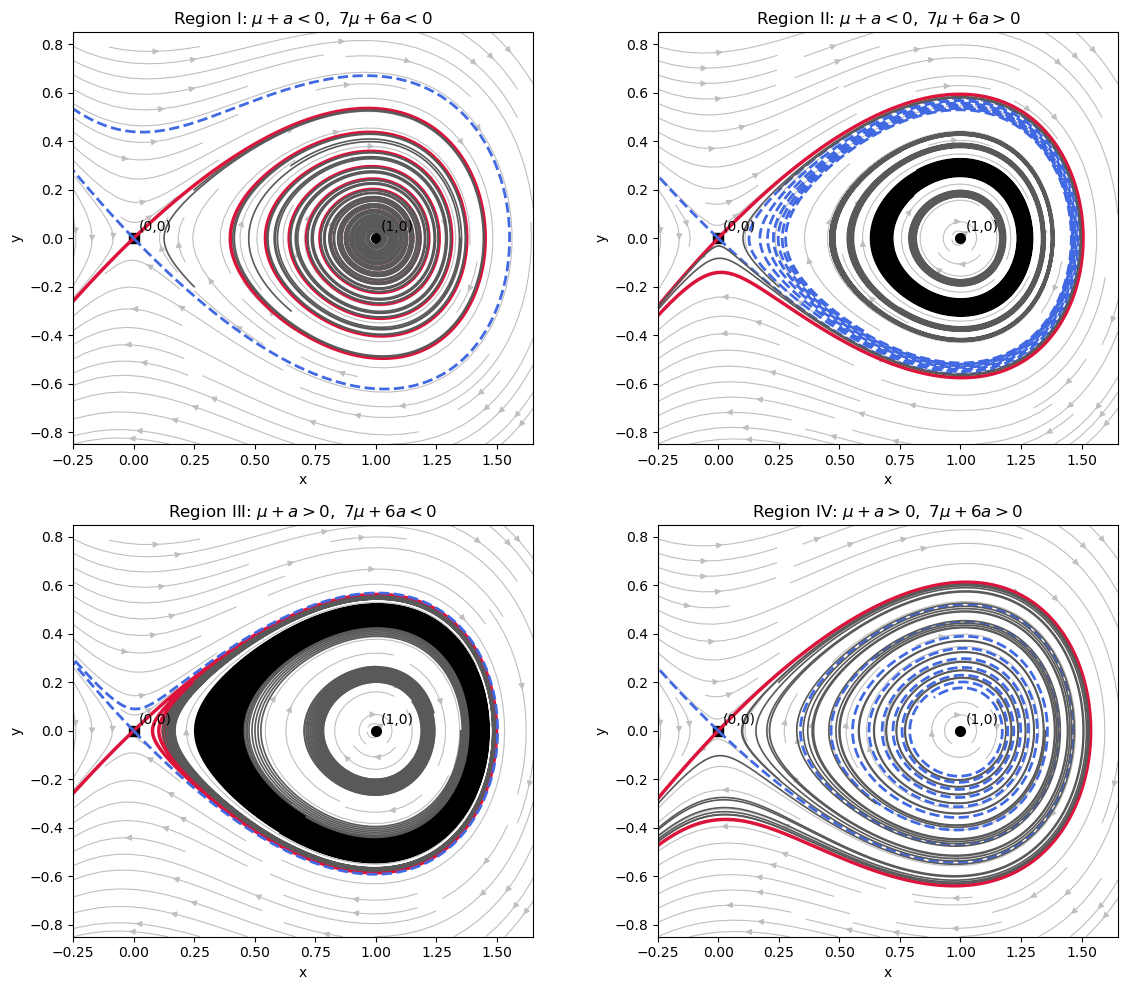

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Region I: stable focus, no cycle
plot_phase_portrait(
    axs[0, 0],
    mu=-0.08, a=0.02,
    title=r"Region I: $\mu+a<0,\ 7\mu+6a<0$"
)

# Region II: stable focus, unstable cycle
plot_phase_portrait(
    axs[0, 1],
    mu=0.08, a=-0.085,
    title=r"Region II: $\mu+a<0,\ 7\mu+6a>0$",
    cycle="unstable",
    cycle_seed=(1.18, 0.02),
    T_cycle=300.0
)

# Region III: unstable focus, stable cycle
plot_phase_portrait(
    axs[1, 0],
    mu=-0.08, a=0.09,
    title=r"Region III: $\mu+a>0,\ 7\mu+6a<0$",
    cycle="stable",
    cycle_seed=(1.25, 0.0),
    T_cycle=300.0
)

# Region IV: unstable focus, no cycle
plot_phase_portrait(
    axs[1, 1],
    mu=0.08, a=-0.04,
    title=r"Region IV: $\mu+a>0,\ 7\mu+6a>0$"
)

plt.tight_layout()
plt.show()

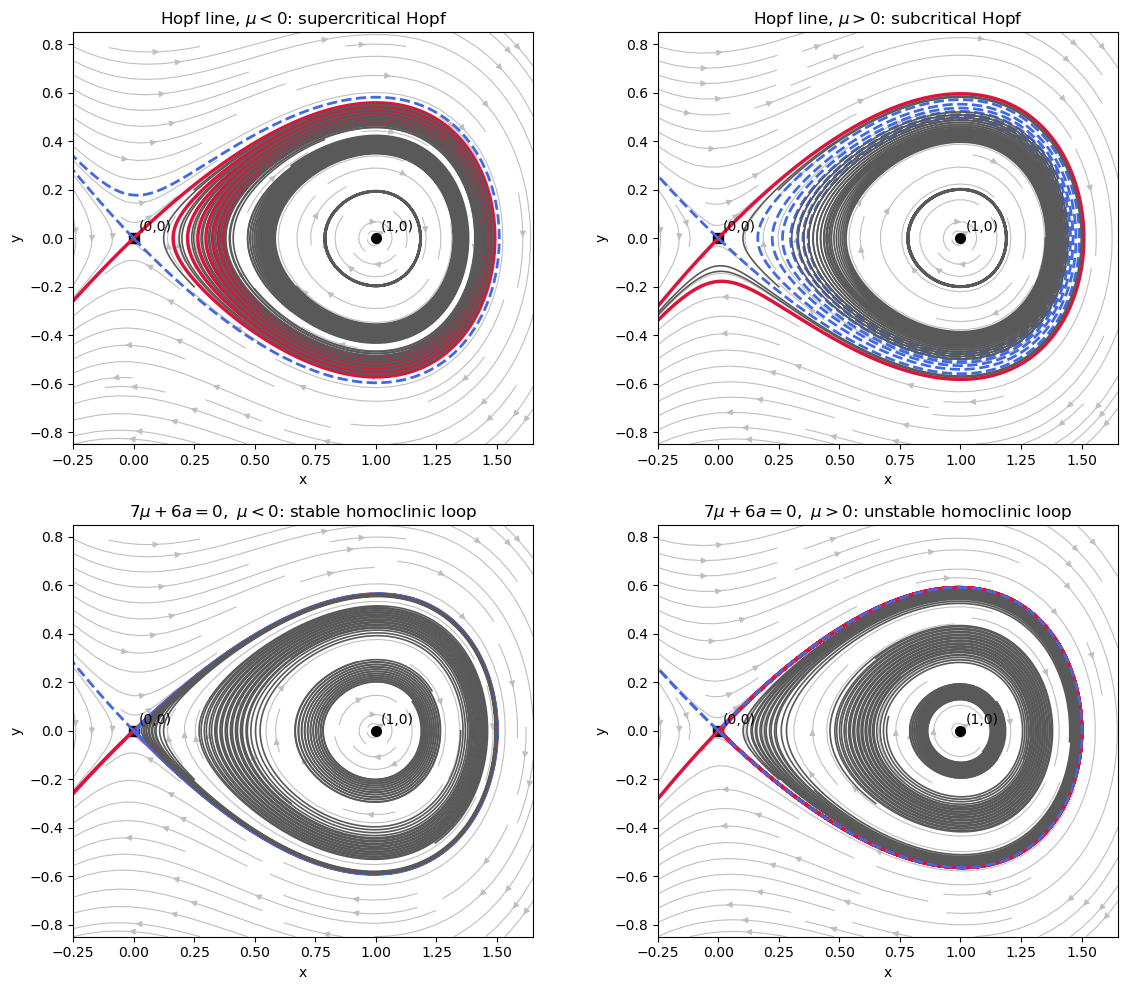

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Hopf, mu < 0 : supercritical
plot_phase_portrait(
    axs[0, 0],
    mu=-0.08, a=0.08,
    title=r"Hopf line, $\mu<0$: supercritical Hopf"
)

# Hopf, mu > 0 : subcritical
plot_phase_portrait(
    axs[0, 1],
    mu=0.08, a=-0.08,
    title=r"Hopf line, $\mu>0$: subcritical Hopf"
)

# Homoclinic, mu < 0 : stable homoclinic loop
plot_phase_portrait(
    axs[1, 0],
    mu=-0.08, a=(7/6)*0.08,
    title=r"$7\mu+6a=0,\ \mu<0$: stable homoclinic loop"
)

# Homoclinic, mu > 0 : unstable homoclinic loop
plot_phase_portrait(
    axs[1, 1],
    mu=0.08, a=-(7/6)*0.08,
    title=r"$7\mu+6a=0,\ \mu>0$: unstable homoclinic loop"
)

plt.tight_layout()
plt.show()

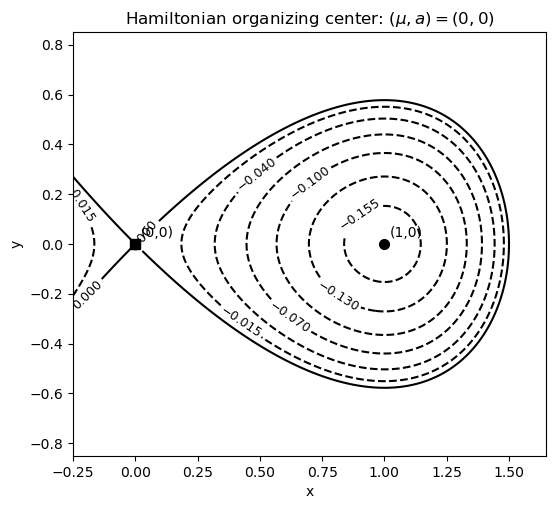

In [8]:
x = np.linspace(-0.25, 1.65, 600)
y = np.linspace(-0.85, 0.85, 600)
X, Y = np.meshgrid(x, y)
HH = H(X, Y)

fig, ax = plt.subplots(figsize=(7, 5.5))
levels = [-0.155, -0.13, -0.10, -0.07, -0.04, -0.015, 0.0]
cs = ax.contour(X, Y, HH, levels=levels, colors="black")
ax.clabel(cs, inline=True, fontsize=9)

ax.plot(0.0, 0.0, "ks", ms=7)
ax.plot(1.0, 0.0, "ko", ms=7)
ax.text(0.02, 0.03, "(0,0)", fontsize=10)
ax.text(1.02, 0.03, "(1,0)", fontsize=10)

ax.set_xlim(-0.25, 1.65)
ax.set_ylim(-0.85, 0.85)
ax.set_aspect("equal")
ax.set_title(r"Hamiltonian organizing center: $(\mu,a)=(0,0)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()